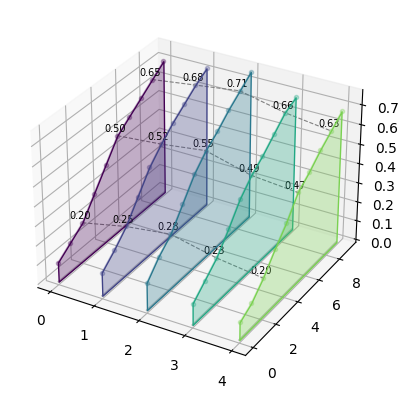

In [11]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
import numpy as np

def plot_line(axs, X, Y, Z, index, x_label_indices, color):
    """绘制一条折线面和相应的0值线，并填充其与地面之间的区域。"""
    axs.plot(Y[index], X[index], Z[index], color=color, linestyle='-', linewidth=1, marker='o', markersize=3, alpha=0.3)
    axs.plot(Y[index], X[index], np.zeros_like(Z[index]), color='gray', alpha=0.5)

    # 填充z值与0值之间的平面
    polygon = [[Y[index, 0], X[index, 0], 0], [Y[index, -1], X[index, -1], 0]]
    polygon += [[Y[index, j], X[index, j], Z[index, j]] for j in range(X.shape[1]-1, -1, -1)]
    axs.add_collection3d(Poly3DCollection([polygon], color=color, alpha=0.3))

    # 标注数值
    for k in x_label_indices:
        axs.text(Y[index, k] - 0.05, X[index, k], Z[index, k] + 0.02, f'{Z[index, k]:.2f}', color='black', ha='center', size=7)

def line_3d(x, y, z, x_label_indices):
    """展示每个变量的时序变化的3D折线图。"""
    if z.shape != (len(y), len(x)):
        return -1

    X, Y = np.meshgrid(x, y)
    fig = plt.figure()
    axs = fig.add_subplot(111, projection='3d')

    for i in range(len(y)):
        color = plt.cm.viridis(i / len(y))
        plot_line(axs, X, Y, z, i, x_label_indices, color)

    for k in x_label_indices:
        axs.plot(Y[:, k], X[:, k], z[:, k], linestyle='--', linewidth=0.8, color='gray')

    axs.grid()
    return fig

# 定义数据
time = np.arange(0, 10, 1)
variables = np.arange(5)
z = np.array([
    [0.10, 0.15, 0.20, 0.30, 0.40, 0.50, 0.55, 0.60, 0.65, 0.70],
    [0.12, 0.18, 0.25, 0.35, 0.45, 0.52, 0.58, 0.63, 0.68, 0.72],
    [0.14, 0.22, 0.28, 0.38, 0.48, 0.55, 0.60, 0.66, 0.71, 0.76],
    [0.11, 0.17, 0.23, 0.32, 0.42, 0.49, 0.54, 0.60, 0.66, 0.69],
    [0.09, 0.13, 0.20, 0.29, 0.37, 0.47, 0.52, 0.58, 0.63, 0.68]
])

# 绘制并保存图像
fig = line_3d(time, variables, z, [2, 5, 8])
fig.savefig('3d_line_plot.png')
plt.show()
plt.close(fig)  # 关闭图形，释放内存


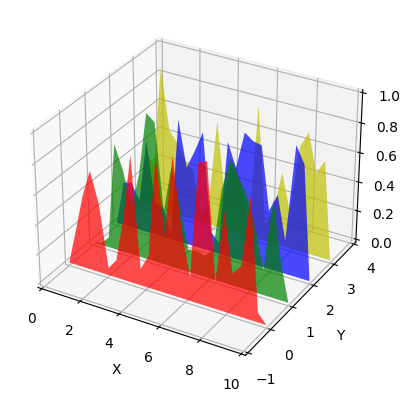

In [17]:
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.collections import PolyCollection
import matplotlib.pyplot as plt
from matplotlib import colors as mcolors
import numpy as np

def create_verts(xs, zs):
    """生成折线的顶点数据"""
    verts = []
    for z in zs:
        ys = np.random.rand(len(xs))
        ys[0], ys[-1] = 0, 0
        verts.append(list(zip(xs, ys)))
    return verts

def set_axes_labels(ax, xlim, ylim, zlim):
    """设置坐标轴标签及范围"""
    ax.set_xlabel('X')
    ax.set_xlim3d(*xlim)
    ax.set_ylabel('Y')
    ax.set_ylim3d(*ylim)
    ax.set_zlabel('Z')
    ax.set_zlim3d(*zlim)

def cc(arg, alpha=0.6):
    """简化颜色设置函数"""
    return mcolors.to_rgba(arg, alpha=alpha)

def plot_3d_surface():
    """绘制 3D 折线面图"""
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')  # 使用 add_subplot 替代 gca

    xs = np.linspace(0, 10, 25)  # 数据点调整为 25 个
    zs = np.arange(0, 4, 1)  # Z 轴范围调整为 [0, 1, 2, 3]
    verts = create_verts(xs, zs)

    colors = ['r', 'g', 'b', 'y']  # 颜色列表
    poly = PolyCollection(verts, facecolors=[cc(c) for c in colors])
    poly.set_alpha(0.7)
    ax.add_collection3d(poly, zs=zs, zdir='y')

    # 设置坐标轴范围
    set_axes_labels(ax, xlim=(0, 10), ylim=(-1, 4), zlim=(0, 1))

    plt.savefig('3d_1.png', dpi=300)
    plt.show()
    

# 调用主函数绘图
plot_3d_surface()


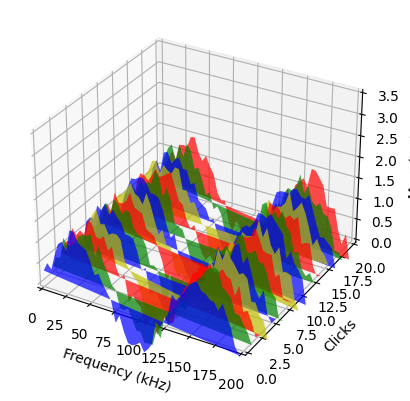

In [27]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.collections import PolyCollection
import numpy as np
from matplotlib import colors as mcolors

def cc(arg):
    """将颜色转化为带透明度的 RGBA"""
    return mcolors.to_rgba(arg, alpha=0.6)

# 创建频率和点击次数的网格数据
frequency = np.linspace(0, 200, 50)  # X轴频率范围
clicks = np.linspace(0, 20, 15)  # Y轴点击次数范围
verts = []

for c in clicks:
    magnitude = np.sin(frequency * 0.05) + np.random.rand(len(frequency)) * 0.5
    verts.append(list(zip(frequency, magnitude)))

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# 使用颜色列表
colors = ['b', 'g', 'r', 'y']

# 创建PolyCollection
poly = PolyCollection(verts, facecolors=[cc(colors[i % len(colors)]) for i in range(len(clicks))])
poly.set_alpha(0.7)

# 添加到3D图中
ax.add_collection3d(poly, zs=clicks, zdir='y')

# 设置轴标签和范围
ax.set_xlabel('Frequency (kHz)')
ax.set_xlim(0, 200)
ax.set_ylabel('Clicks')
ax.set_ylim(0, 20)
ax.set_zlabel('Magnitude')
ax.set_zlim(0, 3.5)

plt.savefig('3d_2.png', dpi=300)
plt.show()


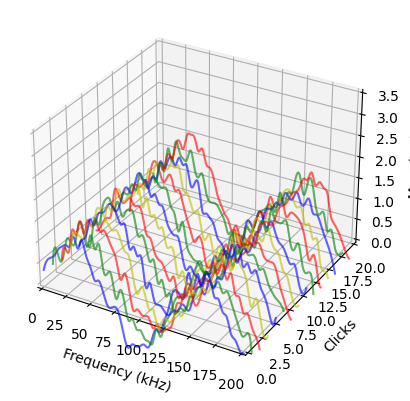

In [29]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
from matplotlib import colors as mcolors
from scipy import interpolate

def cc(arg):
    """将颜色转化为带透明度的 RGBA"""
    return mcolors.to_rgba(arg, alpha=0.6)

# 创建频率和点击次数的网格数据
frequency = np.linspace(0, 200, 50)  # X轴频率范围
clicks = np.linspace(0, 20, 15)  # Y轴点击次数范围
verts = []

for c in clicks:
    magnitude = np.sin(frequency * 0.05) + np.random.rand(len(frequency)) * 0.5
    verts.append(list(zip(frequency, magnitude)))

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# 使用颜色列表
colors = ['b', 'g', 'r', 'y']

# 将散点替换为平滑曲线
for i, c in enumerate(clicks):
    vert = verts[i]
    freq, mag = zip(*vert)  # 解压频率和幅度

    # 使用 splprep 和 splev 进行平滑插值
    tck, u = interpolate.splprep([freq, mag], s=0)  # tck 是插值曲线的描述，u 是参数化值
    freq_smooth, mag_smooth = interpolate.splev(np.linspace(0, 1, 400), tck)  # 插值出更多点，变得平滑

    ax.plot(freq_smooth, [c] * len(freq_smooth), mag_smooth, color=cc(colors[i % len(colors)]))  # 绘制平滑曲线

# 设置轴标签和范围
ax.set_xlabel('Frequency (kHz)')
ax.set_xlim(0, 200)
ax.set_ylabel('Clicks')
ax.set_ylim(0, 20)
ax.set_zlabel('Magnitude')
ax.set_zlim(0, 3.5)

plt.savefig('3d_3.png', dpi=300)
plt.show()
